# 06 - Empirical thesis figures

Compact, thesis-ready figures using the empirical PTO, black-box, and DFL result files. Run notebooks 02–04 first.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'empirical' / 'results').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS
RESULTS = ROOT / 'empirical' / 'results'; OUT = ROOT / 'empirical' / 'figures' / '06_thesis_figures'; OUT.mkdir(parents=True, exist_ok=True)
def load(split):
    base = pd.read_csv(RESULTS/'pto'/f'pto_quarterly_pd_irb_predictions_{split}.csv', parse_dates=['date'])
    base = base.rename(columns={c: c.replace('_mlp', '_pto_mlp').replace('_linear', '_pto_linear').replace('_persistence', '_pto_persistence') for c in base.columns if c.startswith(('alpha_hat_', 'regret_', 'utility_', 'pd_q_hat_', 'pd_a_hat_', 'c_q_hat_', 'k_irb_hat_'))})
    for family in ['blackbox','dfl']:
        other = pd.read_csv(RESULTS/family/f'{family}_quarterly_pd_irb_predictions_{split}.csv', parse_dates=['date'])
        cols = ['date'] + [c for c in other.columns if c not in base.columns]
        base = base.merge(other[cols], on='date', how='inner')
    return base.sort_values('date')
data = {s:load(s) for s in ['modern','stress']}
COLORS = {'pto_mlp':MINOU_COLORS['teal'],'blackbox_mlp':MINOU_COLORS['navy'],'dfl_mlp':MINOU_COLORS['sage'],'oracle':MINOU_COLORS['coral'],'persistence':MINOU_COLORS['grey']}


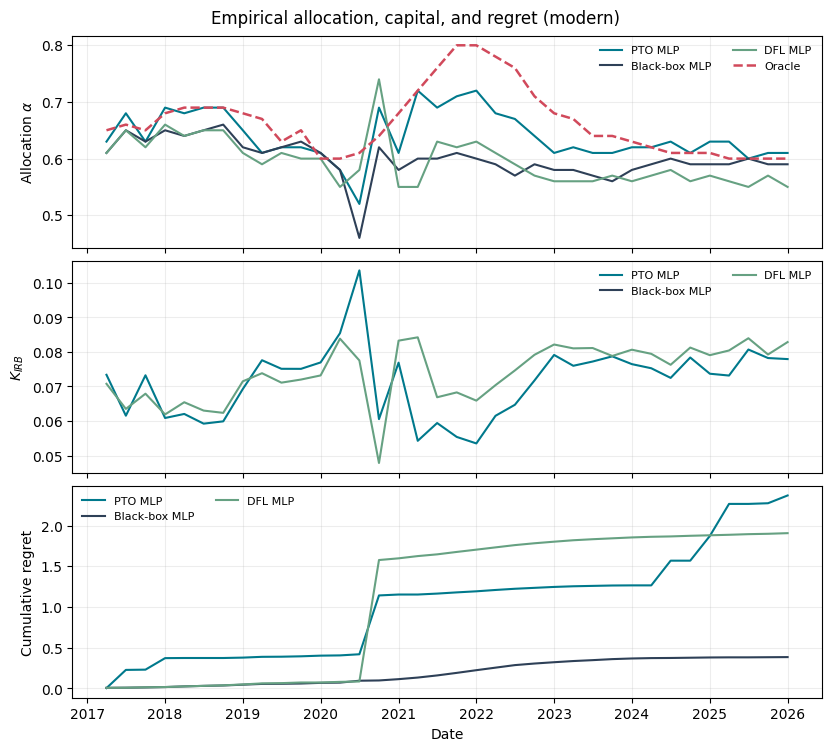

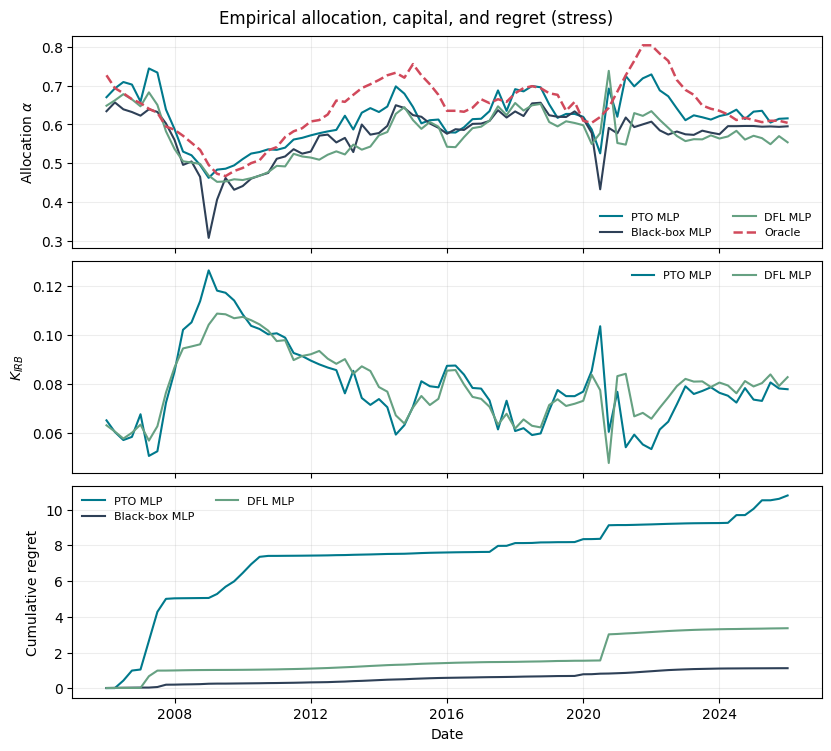

In [2]:
for split, df in data.items():
    fig, axes = plt.subplots(3, 1, figsize=(8.2, 7.4), sharex=True, constrained_layout=True)
    for m, label in [('pto_mlp','PTO MLP'),('blackbox_mlp','Black-box MLP'),('dfl_mlp','DFL MLP')]:
        if f'alpha_hat_{m}' in df: axes[0].plot(df['date'], df[f'alpha_hat_{m}'], color=COLORS[m], lw=1.5, label=label)
        if f'k_irb_hat_{m}' in df: axes[1].plot(df['date'], df[f'k_irb_hat_{m}'], color=COLORS[m], lw=1.5, label=label)
        if f'regret_{m}' in df: axes[2].plot(df['date'], df[f'regret_{m}'].cumsum(), color=COLORS[m], lw=1.5, label=label)
    axes[0].plot(df['date'], df['alpha_oracle'], '--', color=COLORS['oracle'], lw=1.8, label='Oracle')
    axes[0].set_ylabel(r'Allocation $\alpha$'); axes[1].set_ylabel(r'$K_{IRB}$'); axes[2].set_ylabel('Cumulative regret'); axes[2].set_xlabel('Date')
    for ax in axes: ax.grid(alpha=.22); ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.suptitle(f'Empirical allocation, capital, and regret ({split})')
    fig.savefig(OUT/f'{split}_main_thesis_figure.png', dpi=300, bbox_inches='tight'); plt.show()


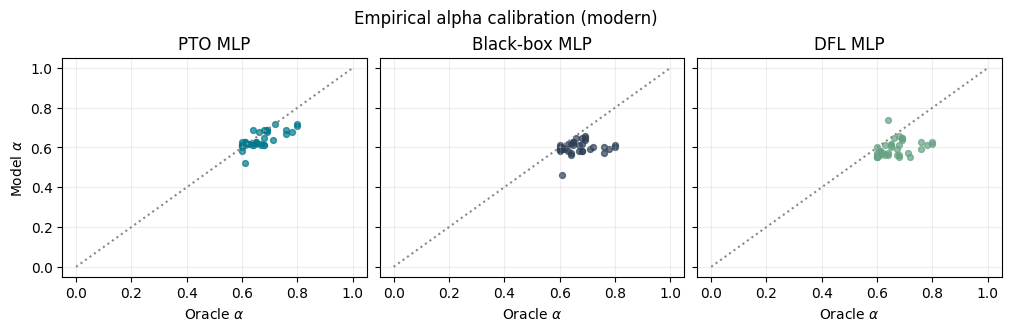

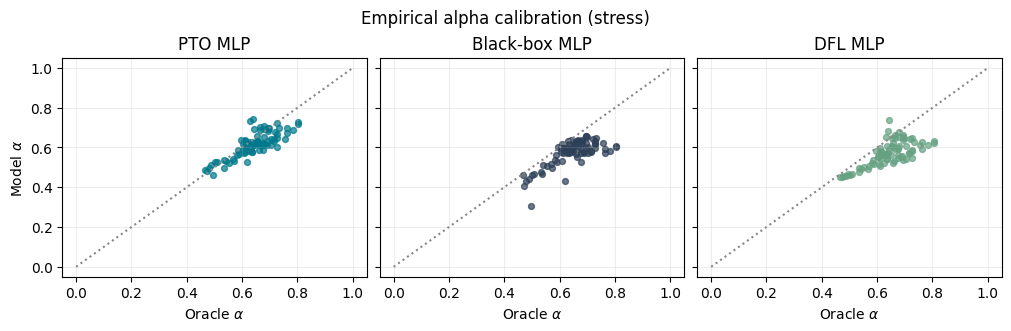

In [3]:
# Direct model comparison: alpha against the foresight oracle.
for split, df in data.items():
    models = [('pto_mlp','PTO MLP'),('blackbox_mlp','Black-box MLP'),('dfl_mlp','DFL MLP')]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharex=True, sharey=True, constrained_layout=True)
    for ax, (m, label) in zip(axes, models):
        ax.scatter(df['alpha_oracle'], df[f'alpha_hat_{m}'], s=18, alpha=.7, color=COLORS[m])
        ax.plot([0,1],[0,1], ':', color='#888888'); ax.set_title(label); ax.set_xlabel(r'Oracle $\alpha$'); ax.grid(alpha=.22)
    axes[0].set_ylabel(r'Model $\alpha$'); fig.suptitle(f'Empirical alpha calibration ({split})')
    fig.savefig(OUT/f'{split}_alpha_vs_oracle.png', dpi=300, bbox_inches='tight'); plt.show()


In [4]:
# Export the same headline comparisons for both modern and stress.
for split, df in data.items():
    models = [m for m in ['pto_mlp','blackbox_mlp','dfl_mlp','pto_linear','blackbox_linear','dfl_linear','persistence'] if f'regret_{m}' in df]
    regret = df[[f'regret_{m}' for m in models]].to_numpy(float)
    winners = np.isclose(regret, regret.min(axis=1, keepdims=True), atol=1e-12)
    rows = []
    for j, m in enumerate(models):
        rows.append({'model':m, 'n':len(df), 'mean_regret':np.nanmean(regret[:,j]), 'median_regret':np.nanmedian(regret[:,j]), 'mean_alpha':df[f'alpha_hat_{m}'].mean(), 'win_share':np.nanmean(winners[:,j] / winners.sum(axis=1))})
    pd.DataFrame(rows).sort_values('mean_regret').to_csv(OUT/f'{split}_comparison_summary.csv', index=False)
    dm_rows = []
    for row in models:
        for col in models:
            if row != col:
                d = df[f'regret_{row}'] - df[f'regret_{col}']
                dm_rows.append({'row_model':row, 'column_model':col, 'mean_difference':d.mean()})
    pd.DataFrame(dm_rows).to_csv(OUT/f'{split}_pairwise_regret_comparisons.csv', index=False)


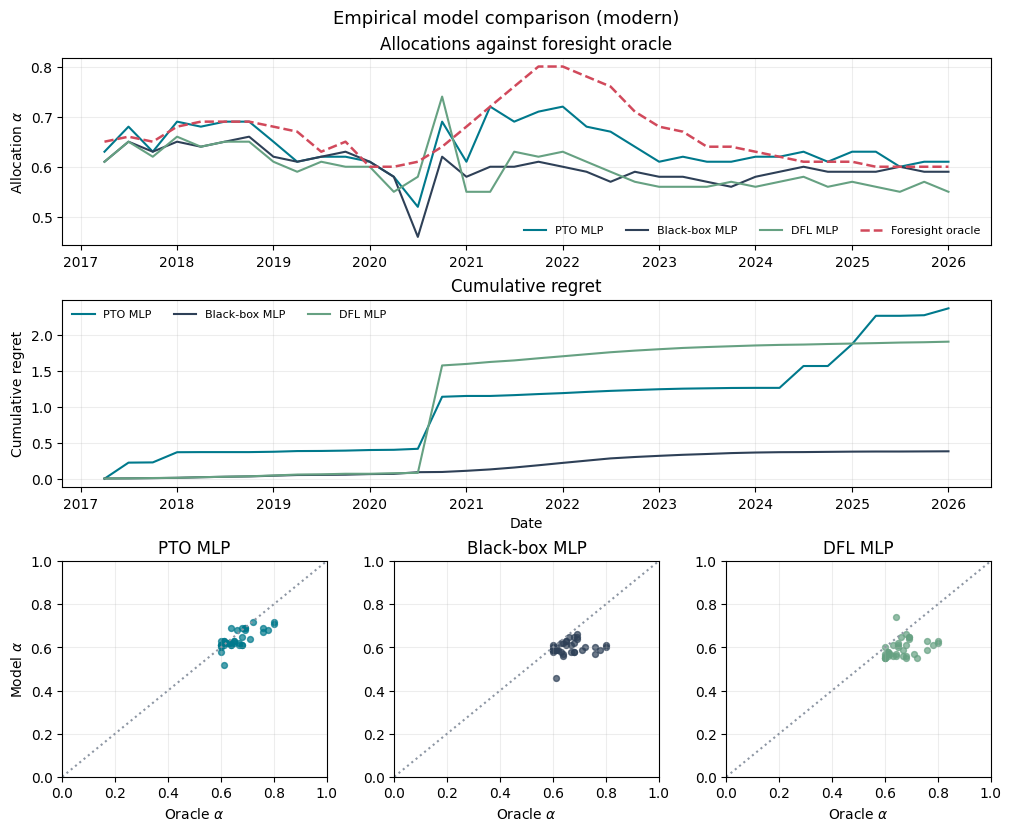

Saved empirical/figures/06_thesis_figures/modern_combined_model_comparison.png


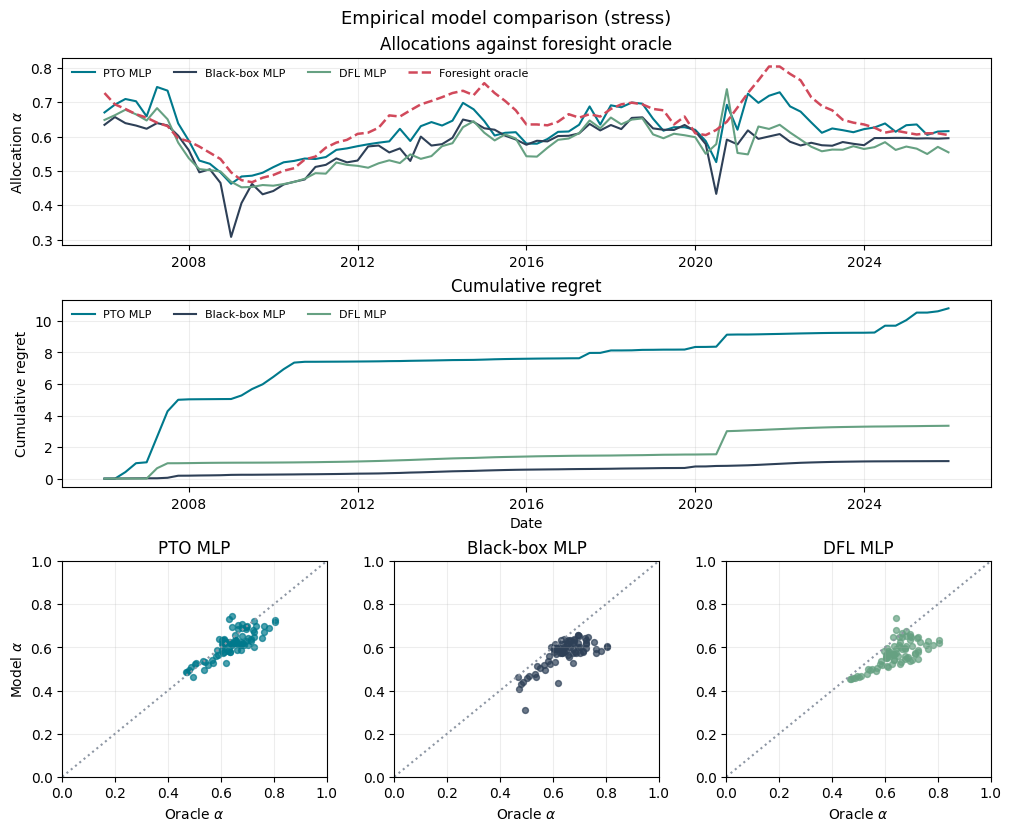

Saved empirical/figures/06_thesis_figures/stress_combined_model_comparison.png


In [5]:
# Combined empirical comparison: paths, cumulative regret, and alpha calibration.
for split, df in data.items():
    models = [('pto_mlp', 'PTO MLP'), ('blackbox_mlp', 'Black-box MLP'), ('dfl_mlp', 'DFL MLP')]
    fig = plt.figure(figsize=(10, 8.2), constrained_layout=True)
    gs = fig.add_gridspec(3, 3, height_ratios=[1.0, 1.0, 1.15])
    ax_alpha = fig.add_subplot(gs[0, :])
    ax_regret = fig.add_subplot(gs[1, :], sharex=ax_alpha)
    cal_axes = [fig.add_subplot(gs[2, i]) for i in range(3)]
    for m, label in models:
        if f'alpha_hat_{m}' in df:
            ax_alpha.plot(df['date'], df[f'alpha_hat_{m}'], color=COLORS[m], lw=1.5, label=label)
        if f'regret_{m}' in df:
            ax_regret.plot(df['date'], df[f'regret_{m}'].cumsum(), color=COLORS[m], lw=1.5, label=label)
    ax_alpha.plot(df['date'], df['alpha_oracle'], '--', color=COLORS['oracle'], lw=1.8, label='Foresight oracle')
    ax_alpha.set_ylabel(r'Allocation $\alpha$'); ax_alpha.set_title('Allocations against foresight oracle')
    ax_regret.set_ylabel('Cumulative regret'); ax_regret.set_xlabel('Date'); ax_regret.set_title('Cumulative regret')
    for ax in [ax_alpha, ax_regret]: ax.grid(alpha=.22); ax.legend(frameon=False, fontsize=8, ncol=4)
    for ax, (m, label) in zip(cal_axes, models):
        if f'alpha_hat_{m}' in df:
            ax.scatter(df['alpha_oracle'], df[f'alpha_hat_{m}'], s=18, alpha=.7, color=COLORS[m])
        ax.plot([0, 1], [0, 1], ':', color=MINOU_COLORS['grey'])
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title(label); ax.set_xlabel(r'Oracle $\alpha$'); ax.grid(alpha=.22)
    cal_axes[0].set_ylabel(r'Model $\alpha$')
    fig.suptitle(f'Empirical model comparison ({split})', fontsize=13)
    path = OUT / f'{split}_combined_model_comparison.png'
    fig.savefig(path, dpi=300, bbox_inches='tight'); plt.show()
    print(f'Saved {path.relative_to(ROOT)}')
